In [1]:
import shutil

source_dir = '../evaluation_setups/fig12_eyerissv2_pe_setup/workload/mobilenet0.5-sparse/uniform'
destination_dir = '../evaluation_setups/Eyeriss_v2/workload_mobilenet'

shutil.copytree(source_dir, destination_dir)

'../evaluation_setups/Eyeriss_v2/workload_mobilenet'

# MICRO 2022 Artifact Evaluation
# Sparseloop: An Analytical Approach To Sparse Tensor Accelerator Modeling
### Yannan N. Wu, Po-An Tsai, Angshuman Parashar, Vivienne Sze, Joel S. Emer

## Context

In this artifact, we provide evaluation setups for the important experiments (the motivating example, validations for accelerator designs, and the case study). Please follow the instructions in each cell to run the evaluations.

For each experiment, we give a *very conservative estimate* of how long the runs will take. The input specifications and related scripts can be found in `../evaluation_setups`. **The easiest way to validate the outputs is to compare the generated figure/table to the figure/table in the paper**, but we do provide a `ref_outputs` folder for each evaluation for more detailed comparison of results if necessary.



***Please note that to allow easier and faster reproduction, for most of the experiments, we directly provide the mappings found by our offline search*** *instead of letting Sparseloop performing online seach for the best mapping.* ***Sparseloop does allow automatic exploration of various mappings*** *as demonstrated in eval1 (more information on tool usage can be found [here](https://accelergy.mit.edu/tutorial.html) and [here](https://accelergy.mit.edu/sparse_tutorial.html)).*


### If you have any questions, please feel free to reach out at timeloop-accelergy@mit.edu. Thanks!




## Eval 1: Data representation format comparison (Fig.1 in paper)

This evaluation compares the processing speed and energy efficiency of two architectures that support different representation formats: 1) bitmask with gating; 2) coordinate list with skipping, running matrix multiplication workloads with various density degrees

### Step 1: Run sweep  ( <5min)

In [ ]:
%%bash
cd ../evaluation_setups/fig1_format_comparison_setup/scripts
echo "input specs at: ../evaluation_setups/fig1_format_comparison_setup/"
chmod +x sweep.sh
time ./sweep.sh

### Step 2: Parse and generate plot
1) run first cell to parse and plot

2) run next cell to display the generated figures

3) compare the figures to Fig.1 in paper

In [ ]:
%%bash
cd ../evaluation_setups/fig1_format_comparison_setup/scripts
time python3 parse_and_plot.py

In [ ]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

cycles_fig = "../evaluation_setups/fig1_format_comparison_setup/outputs/fig_cycles.png"
energy_fig = "../evaluation_setups/fig1_format_comparison_setup/outputs/fig_energy_pJ.png"

display(Image(cycles_fig))
display(Image(energy_fig))

## Eval 2: EyerissV2 PE Validation ( 1. Fig.12 in paper; 2. showcase the main idea presented in Table 5)

We simulate mobilenet0.5 layers on a variation of eyeriss v2 PE with one compute unit.

We show experimental setups for both running evaluations with statistical density model (uniform density model) and actual data based density model. The modeling time is much longer with actual data based model. **This fact showcases the idea presented in Table 5: analytical modeling with statisical density model allows faster modeling.** (*Experiments for Table 5 requires manaul instrumantaion into the source code, which is not convienent for non-developers to setup, so we use this evlauation to showcase the main idea.*)

### Step 1: Run sweep with statistical density modeling (< 3min)

In [ ]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
echo "input specs at: ../evaluation_setups/fig12_eyerissv2_pe_setup/"
time python3 sweep.py

### Step 2: Parse and generte plot

1) run first cell to parse and generate figure

2) run next cell to diplay the generated figure

3) compare to per layer the ground truth and uniform modeling bars in Fig.12 in the paper

In [ ]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
python3 parse_and_plot.py

In [ ]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

fig = "../evaluation_setups/fig12_eyerissv2_pe_setup/outputs/uniform_only/fig.png"

display(Image(fig))

### Step 3: Run autal data evaluation on three layers ( <30 min)

Since actual data based evaluations are slow compared to statistical ones, the default evaluation only run on three layers. Please tune the `--max_layers` knob in the command below if you would like to try more layers.

**Note that this also demonstrate that our modeling speed with the statiscal density models are fast, which is the main idea presented in Table 5 in paper**

In [ ]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
echo "input specs at: ../evaluation_setups/fig12_eyerissv2_pe_setup/"

# update the number of max layers below (<=8) to see more bar groups in fig12, but the run will take longer
time python3 sweep.py --include_actual --max_layers 3

### Step 4: Parse and generate plot


1) run first cell to parse and generate figure

2) run next cell to diplay the generated figure

3) compare to the group of bars for **L07** in Fig.12 in the paper. 
   The main idea here is that compared to `baseline`, `acutal_data` based evlauation is able to accurately capture design behaviors with no error, whereas there is some error due statistical approximations when using the `uniform` distribution.

In [15]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
python3 parse_and_plot.py --include_actual

Traceback (most recent call last):
  File "parse_and_plot.py", line 82, in <module>
    main(base_output_dir)
  File "parse_and_plot.py", line 67, in main
    plot(stats, X_ticks, base_output_dir)
  File "parse_and_plot.py", line 44, in plot
    plt.savefig(os.path.join(base_output_dir, "fig.png"))
  File "/usr/local/bin/conda/lib/python3.8/site-packages/matplotlib/pyplot.py", line 958, in savefig
    res = fig.savefig(*args, **kwargs)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/matplotlib/figure.py", line 3019, in savefig
    self.canvas.print_figure(fname, **kwargs)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/matplotlib/backend_bases.py", line 2319, in print_figure
    result = print_method(
  File "/usr/local/bin/conda/lib/python3.8/site-packages/matplotlib/backend_bases.py", line 1648, in wrapper
    return func(*args, **kwargs)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/matplotlib/_api/deprecation.py", line 412, in wrapper
    return func(*i

CalledProcessError: Command 'b'cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts\npython3 parse_and_plot.py --include_actual\n'' returned non-zero exit status 1.

In [ ]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

fig = "../evaluation_setups/fig12_eyerissv2_pe_setup/outputs/uniform_actual/fig.png"

display(Image(fig))

[  8] Utilization = 0.38 | pJ/Algorithmic-Compute =    7.379 | pJ/Compute =   35.649 | L5[WIO] N2 M4 C6 - L4[IO] M3 P13 C32 Q13X - L3[] Q1 M4Y S3Y - L2[I] Q1 - L1[W] R3 - L0[O] N2 M8 
[ 12] Utilization = 0.38 | pJ/Algorithmic-Compute =    7.387 | pJ/Compute =   35.688 | L5[WIO] N2 M6 C4 - L4[IO] M2 P13 C24 Q13X - L3[] Q1 M4Y S3Y - L2[I] Q1 - L1[W] R3 C2 - L0[O] N2 M8 
[  9] Utilization = 0.38 | pJ/Algorithmic-Compute =    7.635 | pJ/Compute =   36.885 | L5[WIO] N2 M4 C16 - L4[IO] M4 P13 C3 Q13X - L3[] Q1 M2Y C2Y S3Y - L2[I] Q1 - L1[W] R3 C2 - L0[O] N2 M12 
[ 12] Utilization = 0.38 | pJ/Algorithmic-Compute =    7.379 | pJ/Compute =   35.649 | L5[WIO] N2 M4 C6 - L4[IO] M3 P13 C16 Q13X - L3[] Q1 M4Y S3Y - L2[I] Q1 - L1[W] R3 C2 - L0[O] N2 M8 
[  1] Utilization = 0.38 | pJ/Algorithmic-Compute =    2.154 | pJ/Compute =   10.404 | L5[WIO] M8 C12 - L4[IO] M3 N4 P13 Q13X - L3[] Q1 C4Y S3Y - L2[I] Q1 - L1[W] R3 C4 - L0[O] M16 
[  7] Utilization = 0.38 | pJ/Algorithmic-Compute =    2.224 | pJ/Co

## Eval 3: Eyeriss Validation (Table 7 in paper)

We simulate the AlexNet Conv layers on the Eyeriss accelerator, and present the DRAM traffic compression ratio. 


### Step 1: Run sweep (< 5min)

In [23]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
# cd ../evaluation_setups/table7_eyeriss_setup/scripts
# echo "input specs at: ../evaluation_setups/table7_eyeriss_setup/"
#time python3 sweep.py 
# To enable mapspace search, uncomment command below (note that the run will take much longer)
# mapspace search might end up with a slightly different mapping due to runtime randomness
time python3 sweep.py --search_mapping

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 13728
  Factorization options along problem dimension M = 6435
  Factorization options along problem dimension R = 6
  Factorization options along problem dimension S = 6
  Factorization options along problem dimension N = 55
  Factorization options along problem dimension 

[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.137 | pJ/Compute =    9.292 | L7[WIO] S3 P13 R3 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C2 Q13 N2X C3X - L3[I] Q1 - L2[W] C2 - L1[O] M4 - L0[] Q1 
[  0] Utilization = 0.33 | pJ/Algorithmic-Compute =    2.333 | pJ/Compute =   10.145 | L7[WIO] S3 P13 M2 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C2 N2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C3 
[  5] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.307 | pJ/Compute =   10.030 | L7[WIO] P13 R3 M2 S3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C3 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C4 
[  6] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.333 | pJ/Compute =   10.141 | L7[WIO] P13 R3 M2 S3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C3 Q13 N2X - L3[I] Q1 - L2[W] C2 - L1[O] M4 - L0[] C2 
[  0] Utilization = 0.33 | pJ/Algorithmic-Compute =    2.068 | pJ/Compute =    8.989 | L7[WIO] S3 P13 M2 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C2 N2X C

[ 12] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.299 | pJ/Compute =    9.998 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C4 N2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[I] Q1 
[ 14] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.307 | pJ/Compute =   10.030 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C6 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C2 
[ 14] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.162 | pJ/Compute =    9.399 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C6 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[O] C2 
[ 13] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.150 | pJ/Compute =    9.348 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C4 N2X C3X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] Q1 
[ 13] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.143 | pJ/Compute =    9.315 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C4 N2X C3X

[  9] STATEMENT: 3000 invalid mappings (2994 fanout, 6 capacity) found since the last valid mapping, terminating search.
[ 15] Utilization = 0.50 | pJ/Algorithmic-Compute =    3.384 | pJ/Compute =   14.715 | L7[WIO] S3 M2 C12 - L6[] Q13 N2 M2 R3X C4X - L5[I] M16 C2 - L4[O] P13 N2X M2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M2 - L0[] Q1 
[  4] STATEMENT: 3000 invalid mappings (2993 fanout, 7 capacity) found since the last valid mapping, terminating search.
[  6] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.546 | pJ/Compute =   11.070 | L7[WIO] C12 M2 S3 - L6[] Q13 N2 M2 R3X C4X - L5[I] M16 - L4[O] P13 N2X M2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M2 - L0[] C2 
[  6] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.400 | pJ/Compute =   10.435 | L7[WIO] C12 M2 S3 - L6[] Q13 N2 M2 R3X C4X - L5[I] M16 - L4[O] P13 N2X M2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M2 - L0[O] C2 
[ 14] STATEMENT: 3000 invalid mappings (2993 fanout, 7 capacity) found since the last valid mapping, terminating search.
[  



Summary stats for best mapping found by mapper:
  Utilization = 1.00 | pJ/Algorithmic-Compute =    1.938 | pJ/Compute =    8.427
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 8
  Factorization options along problem dimension M = 6336
  Factorization options along problem dimension R = 6
  Factorization options along problem dimension S = 6
  Factorization options a

...

[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.453 | pJ/Compute =    4.089 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 Q2 M8 S5 R5 - L4[O] P7 M4 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] M2 
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.554 | pJ/Compute =    4.257 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 R5 Q2 N2 P2 S5 - L4[O] P7 M4 C2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[] M2 
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.522 | pJ/Compute =    4.203 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 R5 Q2 N2 P2 S5 - L4[O] P7 M4 C2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[I] M2 
[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.401 | pJ/Compute =    4.001 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 Q2 M8 S5 R5 - L4[O] P7 M4 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[I] M2 
[ 10] Utilization = 0.08 | pJ/Algorithmic-Compute =    5.207 | pJ/Compute =    8.678 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] N2 Q2 R5 M8 S5 P2 - L4[O] P7 C6 M4 - L3[I] Q1 - L2[W]

[  6] Utilization = 0.25 | pJ/Algorithmic-Compute =    2.731 | pJ/Compute =    4.552 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] R5 Q2 N2 M8 P2 S5 - L4[O] P7 M4 C2 C3X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] M2 
[  6] Utilization = 0.25 | pJ/Algorithmic-Compute =    2.698 | pJ/Compute =    4.497 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] R5 Q2 N2 M8 P2 S5 - L4[O] P7 M4 C2 C3X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[I] M2 
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.517 | pJ/Compute =    4.195 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 S5 M8 Q2 N2 R5 - L4[O] P7 M4 C2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[I] M2 
[ 14] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.132 | pJ/Compute =    5.220 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] R5 Q2 N2 M8 P2 S5 C2 - L4[O] P7 M4 C3 - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] M2 
[ 14] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.099 | pJ/Compute =    5.165 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] R5 Q2 N2 M8 P2 S5 C2 - L4[O] P7 M4 C3 - L3[I]

[  3] STATEMENT: 3000 invalid mappings (2992 fanout, 8 capacity) found since the last valid mapping, terminating search.
[  6] STATEMENT: 3000 invalid mappings (2993 fanout, 7 capacity) found since the last valid mapping, terminating search.
[  5] STATEMENT: 3000 invalid mappings (2993 fanout, 7 capacity) found since the last valid mapping, terminating search.
[  9] STATEMENT: 3000 invalid mappings (2993 fanout, 7 capacity) found since the last valid mapping, terminating search.
[  7] STATEMENT: 3000 invalid mappings (2993 fanout, 7 capacity) found since the last valid mapping, terminating search.
[ 13] Utilization = 0.83 | pJ/Algorithmic-Compute =    1.961 | pJ/Compute =    3.269 | L7[WIO] P2 Q7 - L6[] M4 C3 Q2X N2X C4X - L5[I] M8 P7 - L4[O] C2 R5 M2 S5X C2X - L3[I] N2 - L2[W] Q1 - L1[O] Q1 - L0[] Q2 P2 M4 
[ 14] Utilization = 0.42 | pJ/Algorithmic-Compute =    2.436 | pJ/Compute =    4.060 | L7[WIO] P2 Q7 - L6[] M4 C3 Q2X N2X C4X - L5[I] P7 M8 - L4[O] R5 C4 M2 S5X - L3[I] N2 - L2[W] 



Summary stats for best mapping found by mapper:
  Utilization = 0.83 | pJ/Algorithmic-Compute =    1.961 | pJ/Compute =    3.269
Running job:  alexnet_conv5
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv5/output
	Running test:  alexnet_conv5
Running job:  alexnet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv1/output
	Running test:  alexnet_conv1
Running job:  alexnet_conv4
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv4/output
	Running test:  alexnet_conv4
Running job:  alexnet_conv3
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv3/output
	Running test:  alexnet_conv3
Running job:  alexnet_conv2
Found and overwrite existing resu


real	2m29.349s
user	23m5.299s
sys	0m0.448s


In [11]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
# cd ../evaluation_setups/table7_eyeriss_setup/scripts
# echo "input specs at: ../evaluation_setups/table7_eyeriss_setup/"
#time python3 sweep.py 
# To enable mapspace search, uncomment command below (note that the run will take much longer)
# mapspace search might end up with a slightly different mapping due to runtime randomness
time python3 sweep.py --search_mapping

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 2772
  Factorization options along problem dimension M = 1287
  Factorization options along problem dimension R = 1
  Factorization options along problem dimension S = 4
  Factorization options along problem dimension N = 36
  Factorization options along problem dimension P

Mapspace construction complete.
Search configuration complete.


[  8] STATEMENT: 3000 invalid mappings (2987 fanout, 13 capacity) found since the last valid mapping, terminating search.
[  7] STATEMENT: 3000 invalid mappings (2987 fanout, 13 capacity) found since the last valid mapping, terminating search.
[  6] STATEMENT: 3000 invalid mappings (2986 fanout, 14 capacity) found since the last valid mapping, terminating search.
[ 15] STATEMENT: 3000 invalid mappings (2986 fanout, 14 capacity) found since the last valid mapping, terminating search.
[ 13] STATEMENT: 3000 invalid mappings (2988 fanout, 12 capacity) found since the last valid mapping, terminating search.
[  9] STATEMENT: 3000 invalid mappings (2987 fanout, 13 capacity) found since the last valid mapping, terminating search.
[ 10] STATEMENT: 3000 invalid mappings (2986 fanout, 14 capacity) found since the last valid mapping, terminating search.
[ 11] STATEMENT: 3000 invalid mappings (2985 fanout, 15 capacity) found since the last valid mapping, terminating search.
[ 14] STATEMENT: 3000 in


MESSAGE: no valid mappings found within search criteria. Some suggestions:
(1) Observe each mapper thread's termination message. If it terminated due to
    consecutive failed mappings, it will tell you the number of mappings that
    failed because of a spatial fanout violation and the number that failed
    because of a buffer capacity violation.
(2) Check your architecture configuration (especially mapspace constraints).
    Try to find the offending constraints that are likely to have caused the
    above violations, and disable those constraints.
(3) Try other search algorithms, and relax the termination criteria:
    victory-condition, timeout and/or search-size.
(4) Enable mapper's diagnostics (mapper.diagnostics = True) to track and emit 
    more information about failed mappings.
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/

Mapspace construction complete.
Search configuration complete.


...


MESSAGE: no valid mappings found within search criteria. Some suggestions:
(1) Observe each mapper thread's termination message. If it terminated due to
    consecutive failed mappings, it will tell you the number of mappings that
    failed because of a spatial fanout violation and the number that failed
    because of a buffer capacity violation.
(2) Check your architecture configuration (especially mapspace constraints).
    Try to find the offending constraints that are likely to have caused the
    above violations, and disable those constraints.
(3) Try other search algorithms, and relax the termination criteria:
    victory-condition, timeout and/or search-size.
(4) Enable mapper's diagnostics (mapper.diagnostics = True) to track and emit 
    more information about failed mappings.
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/

Mapspace construction complete.
Search configuration complete.


[  3] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  0] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[ 10] STATEMENT: 3000 invalid mappings (2994 fanout, 6 capacity) found since the last valid mapping, terminating search.
[  1] STATEMENT: 3000 invalid mappings (2997 fanout, 3 capacity) found since the last valid mapping, terminating search.
[  8] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[  9] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  2] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[ 13] STATEMENT: 3000 invalid mappings (2994 fanout, 6 capacity) found since the last valid mapping, terminating search.
[ 15] STATEMENT: 3000 invalid ma


MESSAGE: no valid mappings found within search criteria. Some suggestions:
(1) Observe each mapper thread's termination message. If it terminated due to
    consecutive failed mappings, it will tell you the number of mappings that
    failed because of a spatial fanout violation and the number that failed
    because of a buffer capacity violation.
(2) Check your architecture configuration (especially mapspace constraints).
    Try to find the offending constraints that are likely to have caused the
    above violations, and disable those constraints.
(3) Try other search algorithms, and relax the termination criteria:
    victory-condition, timeout and/or search-size.
(4) Enable mapper's diagnostics (mapper.diagnostics = True) to track and emit 
    more information about failed mappings.
Running job:  alexnet_conv5
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv5/output
	Running test:  alexnet_co


real	0m0.781s
user	0m3.939s
sys	0m0.054s


### Step 2: Parse and generate table

1) run the first cell to parse results and print table entries

2) compare the entries to the second row in table 7 in the paper

***Please note that we used the public 45nm data for energy modeling in this evaluation instead of the 65nm private PDK used in our paper's evaluations.*** *Although the the DRAM compression ratio is not impacted, the energy reported in the raw results can be different. However, we do see significant energy reduction with the gating SAF implemented in this architecture.*

In [57]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper

Eyeriss DRAM Compression Ratioes (read + write)
problem [3, 96, 11, 11, 4, 56, 56]
-----------------------------------------------
utilization 0.4375
-----------------------------------------------
cycles 5203968
-----------------------------------------------
energy_pJ 821062250.2656
-----------------------------------------------
energy_per_mac 1.8782879907024792
-----------------------------------------------
macs 437133312
-----------------------------------------------
energy_breakdown_pJ {'MAC': {'energy': 245144361.3696, 'utilization': 0.4375}, 'reg': {'energy': 0.0, 'storage_access_energy': 0.0, 'read_energy': 0.0, 'temporal_add_energy': 0.0, 'spatial_add_energy': 0.0, 'address_generation_energy': 0.0, 'network_energy': 0.0, 'energy_per_access_per_instance': array([nan, nan, nan]), 'actual_reads_per_instance': array([0, 0, 0]), 'actual_updates_per_instance': array([0, 0, 0]), 'actual_fills_per_instance': array([0, 0, 0]), 'actual_accesses_per_instance': array([0, 0, 0]), 'insta

-----------------------------------------------
bandwidth_and_cycles {'reg': {'cycles': 3010560, 'read_bandwidth': array([0.        , 1.66666667, 0.        ]), 'write_bandwidth': array([0.       , 0.3452381, 0.       ])}, 'psum_spad': {'cycles': 3010560, 'read_bandwidth': array([0.        , 0.        , 1.65833333]), 'write_bandwidth': array([0., 0., 2.])}, 'weight_spad': {'cycles': 3010560, 'read_bandwidth': array([1.66666667, 0.        , 0.        ]), 'write_bandwidth': array([0.0085034, 0.       , 0.       ])}, 'iact_spad': {'cycles': 3010560, 'read_bandwidth': array([0.       , 0.3452381, 0.       ]), 'write_bandwidth': array([0.        , 0.13095238, 0.        ])}, 'glb': {'cycles': 3010560, 'read_bandwidth': array([0., 0., 0.]), 'write_bandwidth': array([0., 0., 0.])}, 'DRAM': {'cycles': 3010560, 'read_bandwidth': array([0., 0., 0.]), 'write_bandwidth': array([0., 0., 0.])}, 'BackingStorage': {'cycles': 3010560, 'read_bandwidth': array([ 0.81632653,  1.57142857, 10.4       ]), 'wri

problem [192, 384, 3, 3, 4, 13, 13]
-----------------------------------------------
utilization 1.0
-----------------------------------------------
cycles 483605
-----------------------------------------------
energy_pJ 337079393.852
-----------------------------------------------
energy_per_mac 0.7514680938129925
-----------------------------------------------
macs 448561152
-----------------------------------------------
energy_breakdown_pJ {'MAC': {'energy': 52071490.76719999, 'utilization': 1.0}, 'reg': {'energy': 69826019.32800001, 'storage_access_energy': 69826019.32800001, 'read_energy': 32146882.560000002, 'temporal_add_energy': 0.0, 'spatial_add_energy': 0.0, 'address_generation_energy': 0.0, 'network_energy': 0.0, 'energy_per_access_per_instance': array([  nan,   nan, 0.072]), 'actual_reads_per_instance': array([      0,       0, 2325440]), 'actual_updates_per_instance': array([      0,       0, 2336256]), 'actual_fills_per_instance': array([     0,      0, 389376]), 'actual_

-----------------------------------------------
bandwidth_and_cycles {'reg': {'cycles': 358226, 'read_bandwidth': array([0.        , 4.34782512, 0.        ]), 'write_bandwidth': array([0.        , 0.54347814, 0.        ])}, 'psum_spad': {'cycles': 358226, 'read_bandwidth': array([0.       , 0.       , 4.3327285]), 'write_bandwidth': array([0.        , 0.        , 5.79710015])}, 'weight_spad': {'cycles': 358226, 'read_bandwidth': array([4.34782512, 0.        , 0.        ]), 'write_bandwidth': array([0.02572678, 0.        , 0.        ])}, 'iact_spad': {'cycles': 358226, 'read_bandwidth': array([0.        , 0.54347814, 0.        ]), 'write_bandwidth': array([0.        , 0.20903005, 0.        ])}, 'glb': {'cycles': 358226, 'read_bandwidth': array([0., 0., 0.]), 'write_bandwidth': array([0., 0., 0.])}, 'DRAM': {'cycles': 358226, 'read_bandwidth': array([0., 0., 0.]), 'write_bandwidth': array([0., 0., 0.])}, 'BackingStorage': {'cycles': 358226, 'read_bandwidth': array([ 4.93954096,  1.254180

In [30]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper

Eyeriss DRAM Compression Ratioes (read + write)
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv5/output/total_memory_plot.png


In [27]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper

Eyeriss DRAM Compression Ratioes (read + write)
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv5/output/energy_breakdown_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv5/output/total_energy_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv5/output/total_memory_plot.png


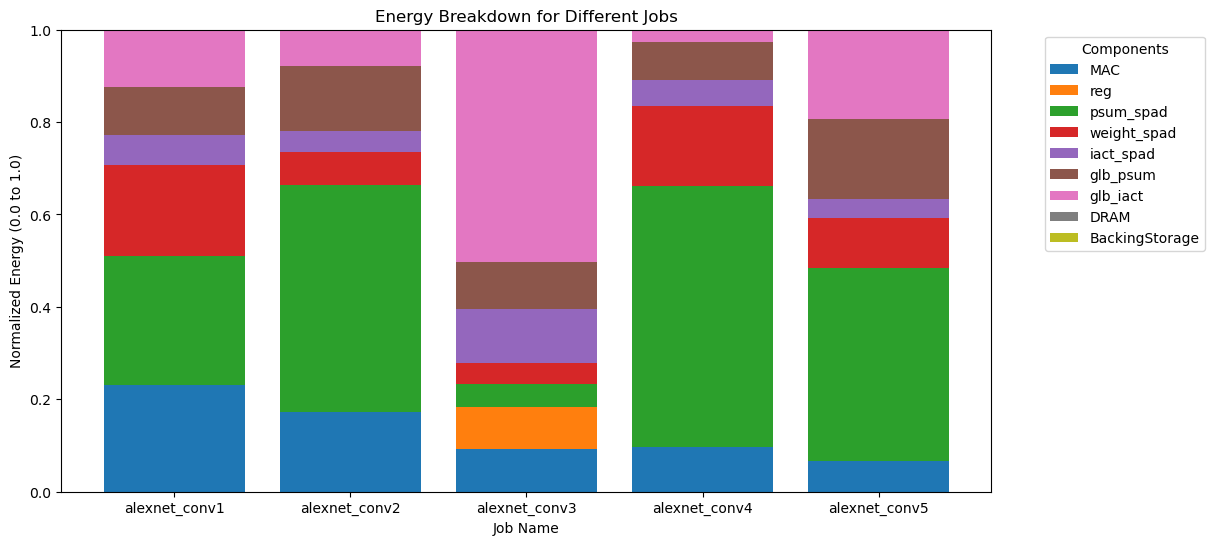

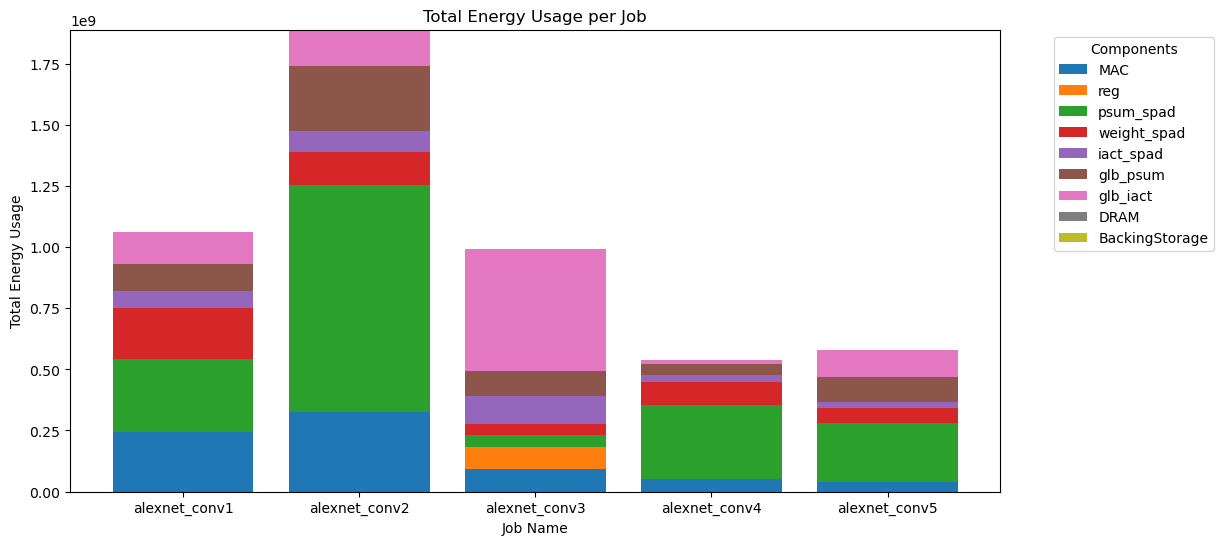

In [28]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/energy_breakdown_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/total_energy_plot.png"))

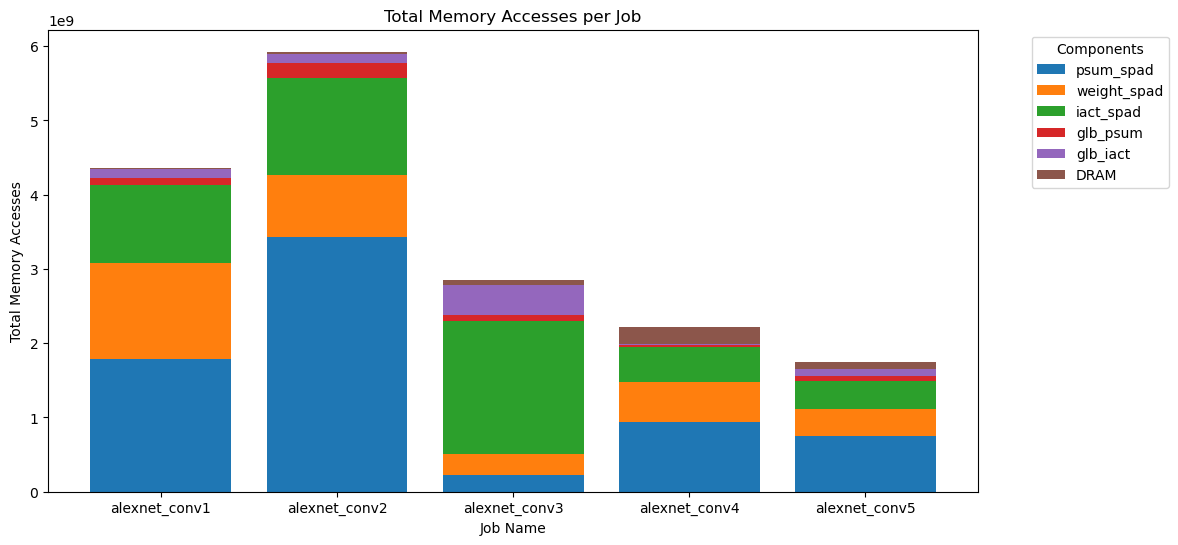

In [31]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/total_memory_plot.png"))

In [67]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper

# If used mapspace search in the previous step
# python3 parse_and_plot.py --stats_prefix timeloop-mapper
#/home/nicoleie/Documents/HA/micro22-sparseloop-artifact/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/outputs/alexnet_conv1/output/timeloop-mapper.stats.txt

parse_and_plot.py:60: RuntimeWarning: divide by zero encountered in true_divide
  print(job_name, ": ",  round(baseline_DRAM_accesses/eyeriss_DRAM_accesses, 1))


Eyeriss DRAM Compression Ratioes (read + write)
alexnet_conv1 :  inf
alexnet_conv2 :  inf
alexnet_conv3 :  inf
alexnet_conv4 :  inf
alexnet_conv5 :  inf


[  3] Utilization = 0.51 | pJ/Algorithmic-Compute =    2.880 | pJ/Compute =   10.472 | L5[WIO] N2 M4 C64 - L4[IO] M4 P13 Q13X - L3[] Q1 M2Y C2Y S3Y - L2[I] N2 - L1[W] R3 C2 - L0[O] M12 
[  9] Utilization = 0.51 | pJ/Algorithmic-Compute =    2.468 | pJ/Compute =    8.975 | L5[WIO] M12 C32 - L4[IO] N4 P13 Q13X - L3[] Q1 M2Y C2Y S3Y - L2[I] Q1 - L1[W] R3 C4 - L0[O] M16 
[ 11] Utilization = 0.51 | pJ/Algorithmic-Compute =    2.637 | pJ/Compute =    9.588 | L5[WIO] M8 C32 - L4[IO] M4 N4 P13 Q13X - L3[] Q1 M2Y C2Y S3Y - L2[I] Q1 - L1[W] R3 C4 - L0[O] M6 
[  2] Utilization = 0.51 | pJ/Algorithmic-Compute =    2.762 | pJ/Compute =   10.043 | L5[WIO] N2 M8 C32 - L4[IO] M3 P13 Q13X - L3[] Q1 C4Y S3Y - L2[I] N2 - L1[W] R3 C2 - L0[O] M16 


## Eval 4: Dual Side Sparse Tensor Core Validation (Fig.13 in paper)

We simulate matrix multiplication workloads with various sparsity degrees running on dual side sparse tensor core design.

### Step 1: Run sweep ( < 5min)

In [ ]:
%%bash
cd ../evaluation_setups/fig13_dstc_setup/scripts
echo "input specs at: ../evaluation_setups/fig13_dstc_setup/"
time python3 sweep.py

### Step 2: Parse and generate plot

1) run first cell to parse and generate figure

2) run next cell to diplay the generated figure

3) compare to Fig.13 in the paper

In [ ]:
%%bash
cd ../evaluation_setups/fig13_dstc_setup/scripts
python3 parse_and_plot.py

In [ ]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

fig = "../evaluation_setups/fig13_dstc_setup/outputs/fig.png"

display(Image(fig))

## Eval 5: Sparse tensor core validation and the related case study (Figure 15 in paper)

We simulate the selected ResNet50 layers on the sparse tensor core (STC) accelerator and compare various sparse designs based on the tensor core setup. 

Please see more details on the various designs validated/explored in Section 6.3.5 and Section 6.4 in the paper. 


### Step 1: Run sweep ( < 8min)

In [4]:
%%bash
cd ../evaluation_setups/fig15_stc_related_setup/scripts
echo "input specs at: ../evaluation_setups/fig15_stc_related_setup/"
time python3 sweep.py
# To enable mapspace search, uncomment command below (note that the run will take much longer)
# mapspace search might end up with a slightly different mapping due to runtime randomness
# time python3 sweep.py --search_mapping

input specs at: ../evaluation_setups/fig15_stc_related_setup/
Utilization = 1.00 | pJ/Compute =    1.832
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.643 | pJ/Compute =    1.643
Utilization = 0.83 | pJ/Algorithmic-Compute =    2.415 | pJ/Compute =    5.489
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.643 | pJ/Compute =    1.643
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.643 | pJ/Compute =    1.643
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.311 | pJ/Compute =    1.311
Utilization = 1.00 | pJ/Compute =    1.845
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.682 | pJ/Compute =    1.682
Utilization = 0.72 | pJ/Algorithmic-Compute =    1.502 | pJ/Compute =    5.564
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.682 | pJ/Compute =    1.682
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.682 | pJ/Compute =    1.682
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.271 | pJ/Compute =    1.271
Utilization = 1.00 | pJ/Compute =    1.781
Utilization = 1.00 


real	1m30.611s
user	0m30.826s
sys	0m1.369s


### Step2: Parse and generate plot

1) run first cell to parse and generate figures

2) run second cell to display the figures

3) compare the generated figure to Fig.15 in the paper

  ***Please note that we used the public 45nm data for energy modeling in this evaluation instead of the 65nm private PDK used in our paper's evaluations.*** As a result, the normalized cycles will match the figure presented in paper, but **the normalized energy will not be an exact match. However, the trends do stay the same for both technology nodes.**


In [5]:
%%bash
cd ../evaluation_setups/fig15_stc_related_setup/scripts
python3 parse_and_plot.py --raw ../outputs/resnet50_selected/*

# If used mapspace search in the previous step
# python3 parse_and_plot.py --raw ../outputs/resnet50_selected/* --stats_prefix timeloop-mapper

dummping stats to  ../csv_results/resnet50_selected-normed-WD-1.0-TC-RF2x-24-bandwidth.csv
Fig saved to  /home/nelliewu/research/workspace/sparse-modeling/micro22-sparseloop-artifact/workspace/2022.micro.artifact/evaluation_setups/fig15_stc_related_setup/outputs/fig_cycles.png
Fig saved to  /home/nelliewu/research/workspace/sparse-modeling/micro22-sparseloop-artifact/workspace/2022.micro.artifact/evaluation_setups/fig15_stc_related_setup/outputs/fig_energy.png


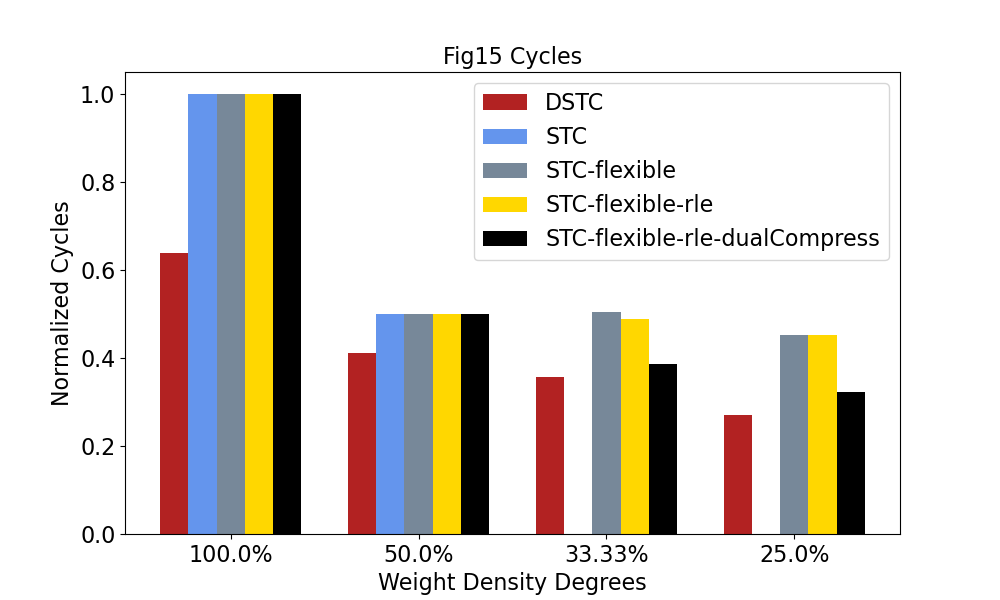

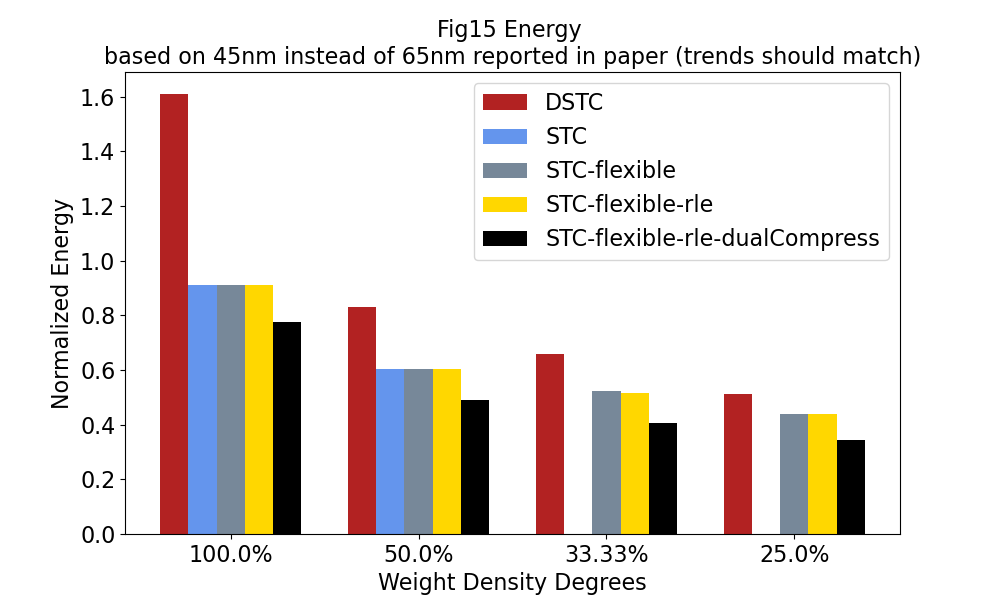

In [6]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

cycles_fig = "../evaluation_setups/fig15_stc_related_setup/outputs/fig_cycles.png"
energy_fig = "../evaluation_setups/fig15_stc_related_setup/outputs/fig_energy.png"

display(Image(cycles_fig))
display(Image(energy_fig))